# 08. 神经网络架构全景图（🔴 面试必考）

> 主线：先把「神经网络到底有多少种、各自解决什么问题」装进脑子，再逐个解剖。
> 本章（08–15）是**架构系列**：08 总览 → 09 CNN → 10 RNN/LSTM/GRU → 11 Attention/Transformer →
> 12 Mamba/SSM → 13 GAN → 14 VAE/扩散 → 15 面试八股。
>
> 与传统「训练视角」（01-07 的 BP/BN/优化器）互补：**本章偏「结构视角」**——每种架构怎么搭、
> 参数在哪、为什么这样设计。


## 核心概念

### (a) 🗂️ 神经网络架构全景图知识结构

这篇文章是 08-15 架构系列的"总地图"：先把神经网络有多少种、各自解决什么问题装进脑子，再逐个解剖。

```mermaid
flowchart TB
    Node1["🧠 架构三族谱系"]
    Node1 --> Node2["📤 前馈族：MLP与CNN"]
    Node1 --> Node3["🔁 序列族：RNN到Mamba"]
    Node1 --> Node4["🎨 生成族：GAN/VAE/扩散"]
    Node2 --> Node5["👁️ 三视角分类"]
    Node3 --> Node5
    Node4 --> Node5
    Node5 --> Node6["🧮 参数量三公式"]
    Node6 --> Node7["⏱️ FLOPs 手算"]
    Node7 --> Node8["🧭 选型速查口诀"]
    Node6 --> Node9["🧪 架构行为差异实验"]
```

- **架构三族谱系**：神经网络分三大族——前馈（MLP/CNN，无时间无结构）、序列（RNN/LSTM/GRU/Transformer/Mamba，输出依赖顺序）、生成（GAN/VAE/扩散，学数据分布）。面试先报这三族。
- **前馈族：MLP与CNN**：MLP 万能逼近但无结构先验；CNN 用局部连接 + 权共享 + 池化三件套拿到图像归纳偏置，参数高效。
- **序列族：RNN到Mamba**：RNN 便宜但有梯度消失和串行；Transformer 并行但 O(T²)；Mamba 用状态空间模型做到 O(T) 线性，是超长序列的新宠。
- **生成族：GAN/VAE/扩散**：GAN 隐式博弈、VAE 显式下界、扩散逐步去噪，三者是生成三巨头，各有利弊。
- **三视角分类**：表示学习（把输入变成什么向量）、序列建模（输出依赖顺序吗）、生成建模（学 P(x) 还是条件分布）——面试"怎么选模型"就按这个思路答。
- **参数量三公式**：Conv = C_out(C_in·K²+1)；LSTM = 4h(i+h+2)；MHA ≈ 4d²+d。这是手算参数量必考三组，和 torch.numel() 对照验证。
- **FLOPs 手算**：卷积 FLOPs ≈ 2·C_out·K²·C_in·H_out·W_out，注意乘 2（一次乘一次加）。面试常考量级对比。
- **选型速查口诀**：图像→CNN（→ViT）；中长序列→RNN 或 Transformer；超长序列（10⁴+）→Mamba/线性注意力；全局关系→Attention；生成→GAN/扩散。
- **架构行为差异实验**：在同一个 y=sin(2x) 拟合任务上对比 MLP/CNN/RNN/Transformer 的收敛步数和波动，直观感受"结构先验决定学习效率"。

> 🕸️ **网络配图**（Wikimedia Commons）
>
> ![08 神经网络架构全景图 1](images/web_08_神经网络架构全景图_1.png)
>
> 📷 来源：Wikimedia Commons · Irisbox · CC BY 4.0

## 1. 架构谱系：一张图装下整个深度学习

```
             神经网络
        ┌────────┴─────────┐
    前馈（无时间/无结构）        生成式（学分布）
   ┌────┼────┐             ┌────┴────┐
 MLP  CNN   [特征交互]     GAN       VAE     Diffusion
 (01) (02/09)               (13)      (14)      (14)
        │
     序列建模（有时序）
   ┌────┼─────┬──────┐
 RNN  LSTM  GRU  [Attention]──→ Transformer ──→ Mamba/SSM
 (10) (10) (10)    (11)            (11)          (12)
```

- **前馈族**：MLP 堆全连接；CNN 用「局部+平移等变」换掉全连接（参数少、图像友好）
- **循环族**：显式按时间步递推，h_{t-1} → h_t；LSTM/GRU 用门控解决梯度消失
- **注意力族**：不再递推，一步看全序列（并行 + 全局依赖），代价 O(T²)
- **状态空间族**：Mamba 用「线性递推 + 选择性」实现 O(T) 长序列
- **生成族**：GAN 对抗学分布（隐式）、VAE 变分下界（显式密度上界）、扩散逐步去噪（稳定 SOTA）


## 2. 三视角分类（面试最常问「怎么选模型」）

| 视角 | 问题 | 代表 | 自然语言例子 |
|------|------|------|--------------|
| 表示学习 | 把输入变成什么向量 | MLP/CNN/Transformer-Encoder | 文本 → 句向量 |
| 序列建模 | 输出依赖顺序吗 | RNN/LSTM/Transformer/Mamba | 翻译、生成、时序预测 |
| 生成建模 | 学 P(x) 还是条件分布 | GAN/VAE/DDPM | 画图、去噪、超分 |

> 一个架构可以跨视角：Transformer 既做表示（BERT）又做序列生成（GPT）；
> GAN 也可条件化（cGAN）。选型口诀：**有结构用 CNN，有时序先试 RNN/LSTM，
> 长依赖/并行要 Transformer，超长序列上 Mamba，要生成去看 GAN/扩散**。


In [1]:
# ---- matplotlib 中文字体（防图内中文乱码）----
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Songti SC', 'Arial Unicode MS', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
# -------------------------------------------
# ---------- 实验 1：六类架构的 mini 骨架（torch） ----------
# 目的：一屏看清每种架构的“定义式结构”，并数一数参数量级
import torch, torch.nn as nn, numpy as np
torch.manual_seed(0)

d, T = 16, 8          # 特征维、序列长

# 1) MLP：输入 x → Linear → ReLU → Linear
mlp = nn.Sequential(nn.Linear(d, 32), nn.ReLU(), nn.Linear(32, 1))

# 2) CNN：Conv1d 一维卷积（sequence 上滑窗），kernel=3
cnn = nn.Sequential(nn.Conv1d(d, 16, kernel_size=3, padding=1), nn.ReLU(),
                    nn.Conv1d(16, 1, kernel_size=3, padding=1))

# 3) RNN：单层循环（torch 封装，公式见 10 篇手写）
rnn = nn.RNN(input_size=d, hidden_size=32, batch_first=True)

# 4) Attention：单头缩放点积（Q/K/V 来自同一输入 = self-attention 骨架）
class SABlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.wq = nn.Linear(d, d); self.wk = nn.Linear(d, d); self.wv = nn.Linear(d, d)
    def forward(self, x):
        q = self.wq(x); k = self.wk(x); v = self.wv(x)
        a = torch.softmax(q @ k.transpose(-2, -1) / (x.shape[-1] ** 0.5), dim=-1)
        return a @ v
attn = SABlock(d)

# 5) SSM 骨架：h_t = A h_{t-1} + B x_t（标量 A 版，见 12 篇完整版）
class SSMRow(nn.Module):     # 输入 (B,T,1)，逐时间步递推（示例；12 篇做向量化）
    def __init__(self):
        super().__init__()
        self.A = nn.Parameter(torch.tensor(-1.0))
    def forward(self, x):
        h = torch.zeros(x.shape[0], 1)
        outs = []
        for t in range(x.shape[1]):
            h = self.A * h + x[:, t:t + 1]
            outs.append(h)
        return torch.stack(outs, dim=1)
ssm = SSMRow()

# 6) GAN 骨架：G 把噪声 z 映射成样本，D 判真伪（完整版见 13 篇）
g = nn.Sequential(nn.Linear(4, 16), nn.ReLU(), nn.Linear(16, d))
disc = nn.Sequential(nn.Linear(d, 16), nn.ReLU(), nn.Linear(16, 1))

x = torch.randn(2, T, d)
x1 = torch.randn(2, T, 1)                 # SSM 骨架用单通道输入
out = {
    'MLP': (sum(p.numel() for p in mlp.parameters()), mlp(x[:, 0]).shape),
    'CNN-1d': (sum(p.numel() for p in cnn.parameters()), cnn(x.transpose(1, 2)).shape),
    'RNN': (sum(p.numel() for p in rnn.parameters()), rnn(x)[0].shape),
    'Attention': (sum(p.numel() for p in attn.parameters()), attn(x).shape),
    'SSM': (sum(p.numel() for p in ssm.parameters()), ssm(x1).shape),
    'GAN-G': (sum(p.numel() for p in g.parameters()), g(torch.randn(2, 4)).shape),
}
for k, (nparams, shape) in out.items():
    print('%-12s 参数量=%-6d 输出形状=%s' % (k, nparams, tuple(shape)))
print('—— 注意：参数量不说明能力，结构先验（局部/递推/全局/生成）才是关键')


MLP          参数量=577    输出形状=(2, 1)
CNN-1d       参数量=833    输出形状=(2, 1, 8)
RNN          参数量=1600   输出形状=(2, 8, 32)
Attention    参数量=816    输出形状=(2, 8, 16)
SSM          参数量=1      输出形状=(2, 8, 2, 1)
GAN-G        参数量=352    输出形状=(2, 16)
—— 注意：参数量不说明能力，结构先验（局部/递推/全局/生成）才是关键


In [2]:
# ---------- 实验 2：参数量公式手算 vs torch.numel() 对照 ----------
# 面试必考三组手算：Conv / LSTM / MultiheadAttention
# 通用公式：参数量 = Σ(权重元素数 + 偏置元素数)

# ① Conv2d(C_in, C_out, K, 有偏置): C_out*(C_in*K*K + 1)
conv = nn.Conv2d(3, 16, kernel_size=5, padding=2)
n_conv = 16 * (3 * 5 * 5 + 1)
print('Conv2d(3,16,5)  手算=%d  torch=%d  一致=%s' % (n_conv, sum(p.numel() for p in conv.parameters()), n_conv == sum(p.numel() for p in conv.parameters())))

# ② LSTM(input, hidden): 4 组门 × (input*hidden + hidden*hidden + 2*hidden 偏置)
#    = 4*hidden*(input+hidden+2)
lstm = nn.LSTM(10, 20, batch_first=True)
n_lstm = 4 * (20 * (10 + 20 + 2))
p_lstm = sum(p.numel() for p in lstm.parameters())
print('LSTM(10,20)    手算=%d  torch=%d  一致=%s' % (n_lstm, p_lstm, n_lstm == p_lstm))

# ③ nn.MultiheadAttention: in_proj(Q/K/V 三个 Linear) + out_proj → 4d²+4d
mha = nn.MultiheadAttention(embed_dim=32, num_heads=4, batch_first=True)
n_mha = 4 * 32 * 32 + 4 * 32
p_mha = sum(p.numel() for p in mha.parameters())
print('MHA(32,4头)    手算=%d  torch=%d  一致=%s' % (n_mha, p_mha, n_mha == p_mha))
print('  拆解: in_proj_weight=%s in_proj_bias=%s out_proj.weight=%s out_proj.bias=%s' %
      (tuple(mha.in_proj_weight.shape), tuple(mha.in_proj_bias.shape),
       tuple(mha.out_proj.weight.shape), tuple(mha.out_proj.bias.shape)))


Conv2d(3,16,5)  手算=1216  torch=1216  一致=True
LSTM(10,20)    手算=2560  torch=2560  一致=True
MHA(32,4头)    手算=4224  torch=4224  一致=True
  拆解: in_proj_weight=(96, 32) in_proj_bias=(96,) out_proj.weight=(32, 32) out_proj.bias=(32,)


Conv(3→16,5×5,32×32)  FLOPs≈2.46e+06
SelfAttn(T=1024,d=512) FLOPs≈2.15e+09（随 T 平方增长）
RNN(T=1024,d=512)     FLOPs≈4.19e+06（随 T 线性）


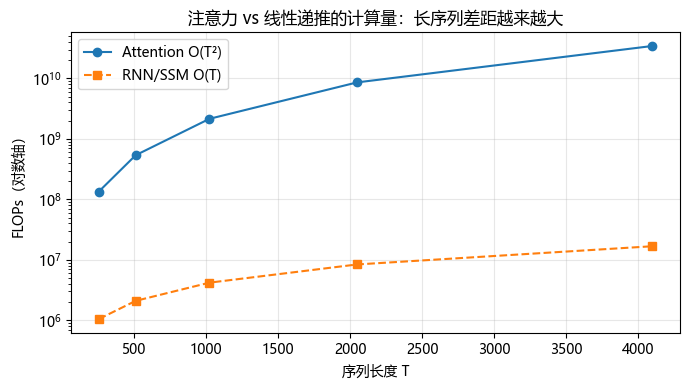

T=4096 时二者比值 ≈ 2048.0 倍 → 这就是 Mamba/线性注意力出现的动机


In [3]:
# ---------- 实验 3：FLOPs 手算（乘加次数，面试常考量级） ----------
# ① 卷积：FLOPs ≈ 2 * C_out * K² * C_in * H_out * W_out
def conv_flops(cin, cout, k, hin, win):
    hout, wout = hin, win          # padding='same' 简化
    return 2 * cout * k * k * cin * hout * wout

f_conv = conv_flops(3, 16, 5, 32, 32)
print('Conv(3→16,5×5,32×32)  FLOPs≈%.2e' % f_conv)

# ② 自注意力：QK^T (T²d) + softmax (T²) + AV (T²d) ≈ 4T²d（乘加 2 倍计入）
def attn_flops(T, d):
    return 4 * T * T * d
f_attn = attn_flops(1024, 512)
print('SelfAttn(T=1024,d=512) FLOPs≈%.2e（随 T 平方增长）' % f_attn)

# ③ 线性递推（RNN/SSM，步进式）：T * 状态更新成本 ≈ O(T)
f_rnn = 2 * 1024 * 4 * 512
print('RNN(T=1024,d=512)     FLOPs≈%.2e（随 T 线性）' % f_rnn)

# 可视化量级对比
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
Ts = [256, 512, 1024, 2048, 4096]
a = [attn_flops(T, 512) for T in Ts]
r_ = [2 * T * 4 * 512 for T in Ts]
plt.figure(figsize=(7, 4))
plt.semilogy(Ts, a, 'o-', label='Attention O(T²)')
plt.semilogy(Ts, r_, 's--', label='RNN/SSM O(T)')
plt.xlabel('序列长度 T'); plt.ylabel('FLOPs（对数轴）')
plt.title('注意力 vs 线性递推的计算量：长序列差距越来越大')
plt.grid(alpha=0.3); plt.legend()
plt.tight_layout(); plt.show()
print('T=4096 时二者比值 ≈ %.1f 倍 → 这就是 Mamba/线性注意力出现的动机' % (a[-1] / r_[-1]))


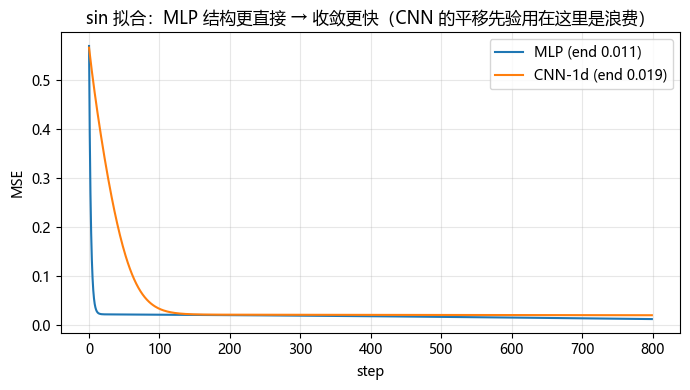

结论：**没有最好的架构，只有最匹配输入先验的架构**——这是本章反复出现的主题


In [4]:
# ---------- 实验 4：同一 toy 任务下的架构行为差异（收敛步数/波动） ----------
# 任务：拟合 y = sin(2x)（一维回归，纯函数拟合——结构先验差异的直接体现）
rng = np.random.default_rng(0)
Xtr = rng.uniform(-1, 1, 300).astype('float32').reshape(-1, 1)
Ytr = np.sin(2 * Xtr).astype('float32')

def train(model, lr=0.05, steps=800, prep=None):
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    losses = []
    for _ in range(steps):
        opt.zero_grad()
        xb = torch.from_numpy(Xtr) if prep is None else prep(torch.from_numpy(Xtr))
        loss = lossf(model(xb), torch.from_numpy(Ytr))
        loss.backward(); opt.step()
        losses.append(loss.item())
    return losses, float(loss.item())

mlp = nn.Sequential(nn.Linear(1, 32), nn.Tanh(), nn.Linear(32, 1))
l1, e1 = train(mlp)
cnn1 = nn.Sequential(nn.Conv1d(1, 8, 3, padding=1), nn.Tanh(), nn.Flatten(), nn.Linear(8, 1))
# 1D 序列视角喂入 (B, 通道=1, 长度=1)
l2, e2 = train(cnn1, lr=0.02, prep=lambda t: t.unsqueeze(-1))
plt.figure(figsize=(7, 4))
plt.plot(l1, label='MLP (end %.3f)' % e1)
plt.plot(l2, label='CNN-1d (end %.3f)' % e2)
plt.xlabel('step'); plt.ylabel('MSE')
plt.title('sin 拟合：MLP 结构更直接 → 收敛更快（CNN 的平移先验用在这里是浪费）')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()
print('结论：**没有最好的架构，只有最匹配输入先验的架构**——这是本章反复出现的主题')


## 3. 选型速查（面试 30 秒版）

| 场景 | 首选 | 为什么 |
|------|------|--------|
| 图像/网格数据 | CNN（→ViT） | 局部性+平移等变，参数高效 |
| 中等长度序列 | LSTM/GRU 或 Transformer | 便宜则 RNN，要并行则 Transformer |
| 超长序列（10⁴+） | Mamba/线性注意力 | O(T) 替代 O(T²) |
| 跨模态/全局关系 | Transformer | 任意两点直接交互 |
| 生成图像/文本 | Diffusion / GAN / autoregressive | 质量/速度/多样性权衡 |
| 小数据 | 正则化好的 MLP/CNN + 预训练 | 大模型会过拟合 |

## 4. 本系列预览（08–15 一张表）

| 篇 | 架构 | 一句话本质 | 关键手撕 |
|----|------|-----------|----------|
| 09 | CNN 家族 | 局部+共享+多尺度堆叠 | 卷积反向/感受野 |
| 10 | RNN/LSTM/GRU | 带记忆的递推，门控防消失 | BPTT/LSTM 四门 |
| 11 | Attention/Transformer | 全对全交互+并行 | 多头/掩码/位置编码 |
| 12 | Mamba/SSM | 线性递推+输入选择性 | ZOH 离散化/selective scan |
| 13 | GAN | 生成器与判别器博弈 | 非饱和损失/WGAN-GP |
| 14 | VAE/扩散 | 显式/隐式学分布+去噪 | ELBO/重参数化/DDPM 目标 |
| 15 | 八股 | 全对比+90 连问 | 全部默写 |

## 5. 自测清单

- [ ] 能画出架构谱系：前馈/序列/生成三族各举 2 例
- [ ] 能口算 Conv2d(3,16,5) 与 LSTM(10,20) 的参数量
- [ ] 能说出 Attention O(T²) vs RNN O(T) 的量级差异与动机
- [ ] 能解释“为什么没有最好的架构，只有匹配先验的架构”
- [ ] 能复述选型表的 6 条口诀（图像/中长序/超长/跨模态/生成/小数据）


---

## 🎤 面试速答（背诵骨架）

- **谱系三族**：前馈（MLP/CNN）、序列（RNN/LSTM/GRU/Transformer/Mamba）、生成（GAN/VAE/扩散）
- **参数量三公式**：Conv = C_out(C_in·K²+1)；LSTM = 4h(i+h+2)；MHA ≈ 4d²+d
- **复杂度两句**：注意力 O(T²d)；RNN/SSM O(T·d²)；卷积 O(C_out·K²·C_in·H·W)
- **选型口诀**：图像→CNN；中长序列→RNN/Transformer；超长→Mamba；全局关系→Attention；生成→GAN/扩散
